In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# load the dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [24]:
df.shape
df.info()
df.describe().T
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [25]:
# Checking for missing values and duplicates 
df.isnull().sum()
df.duplicated().sum()

np.int64(1)

In [26]:
df = df.drop_duplicates()
df.shape

(302, 14)

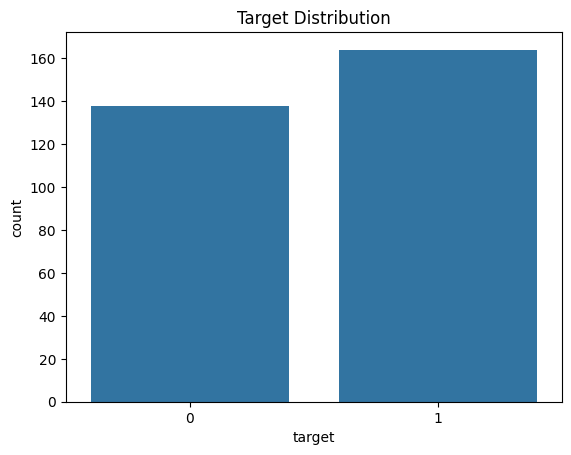

In [27]:
# understanding the target variable distribution
df['target'].value_counts()
df['target'].value_counts(normalize=True)
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

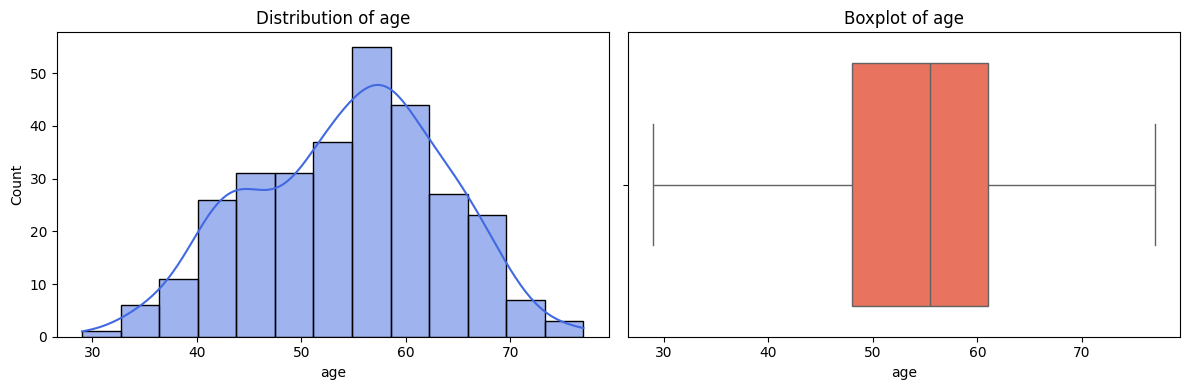

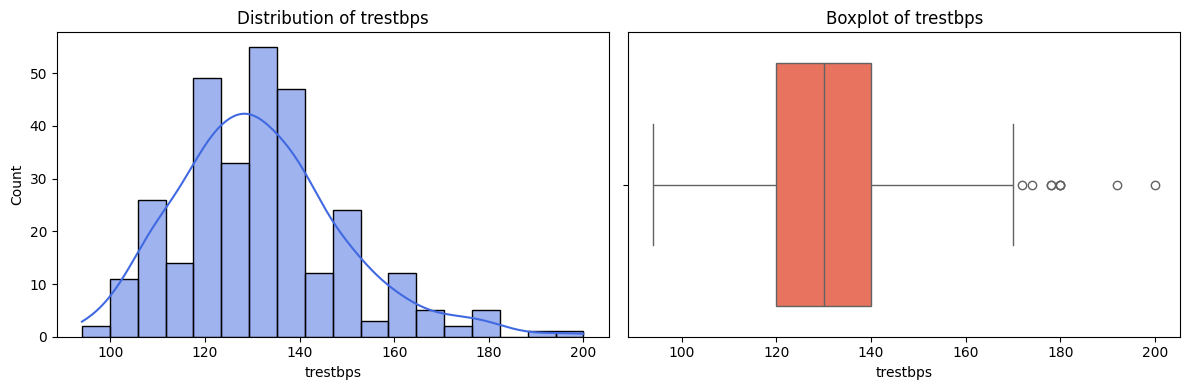

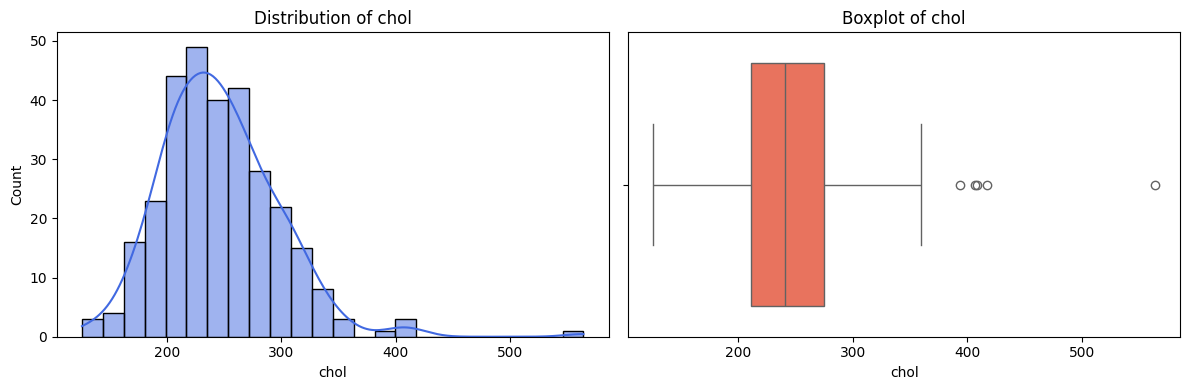

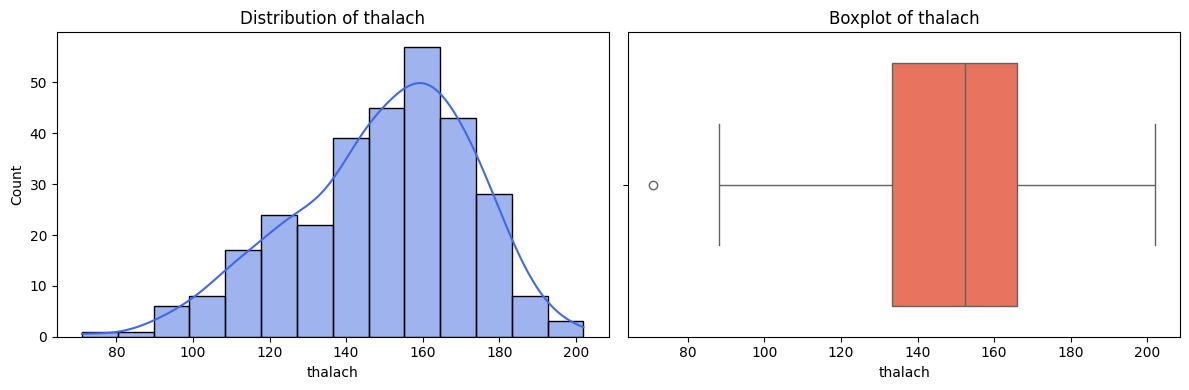

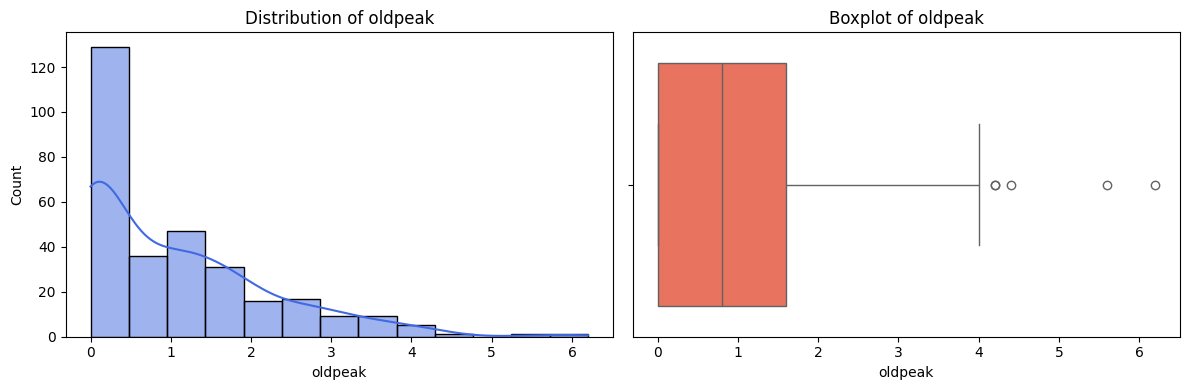

In [28]:
# univariate analysis of continuous features


categorical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for col in continuous_cols:
    plt.figure(figsize=(12, 4))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color="royalblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    
    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color="tomato")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    
    plt.tight_layout()
    plt.show()


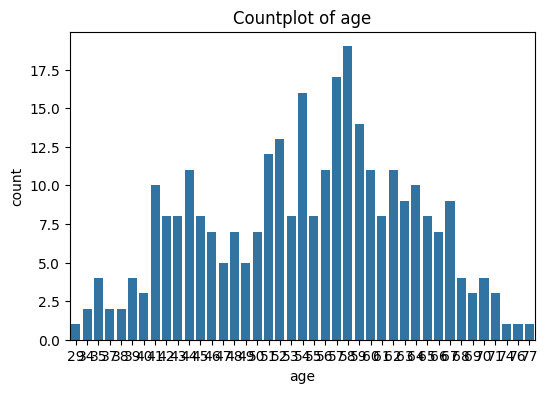

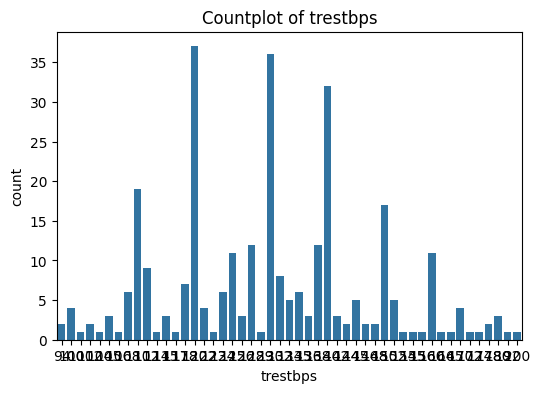

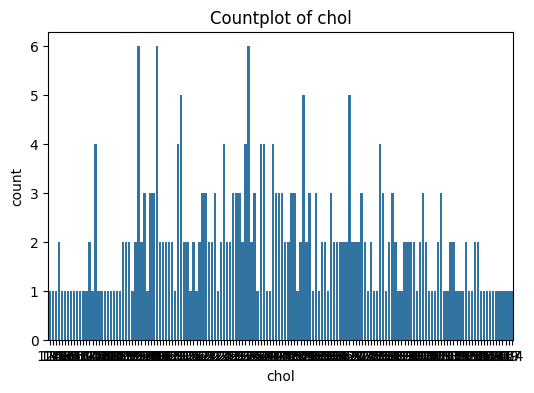

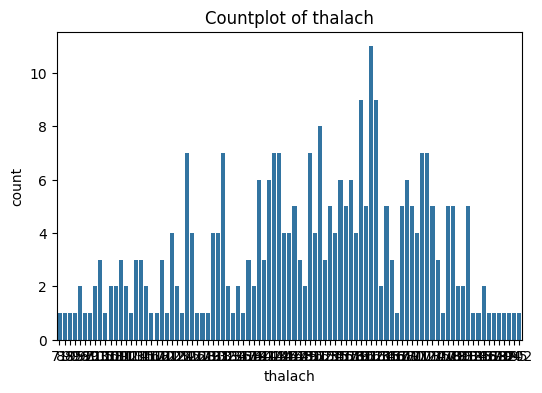

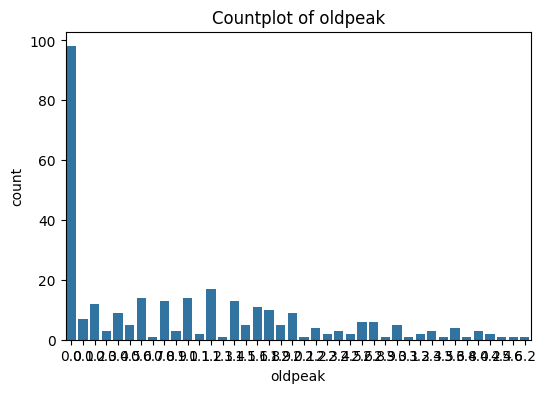

In [29]:
# plot countplots for categorical features

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot of {col}")
    plt.show()


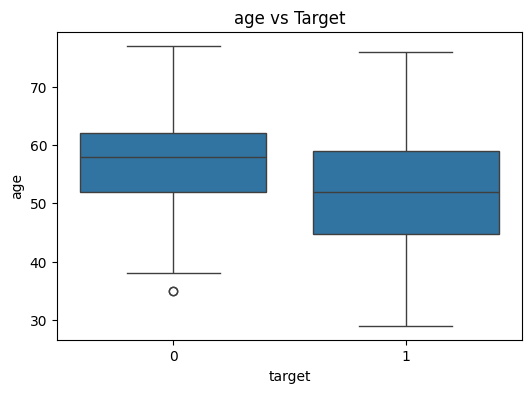

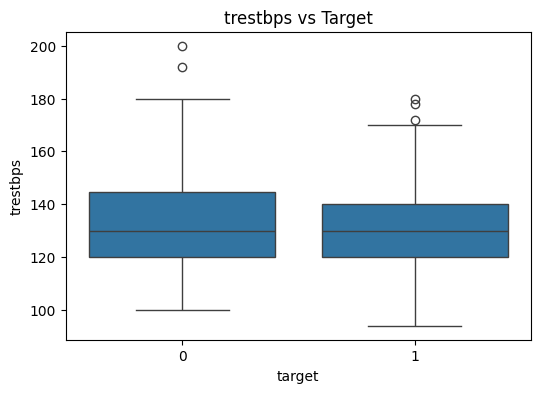

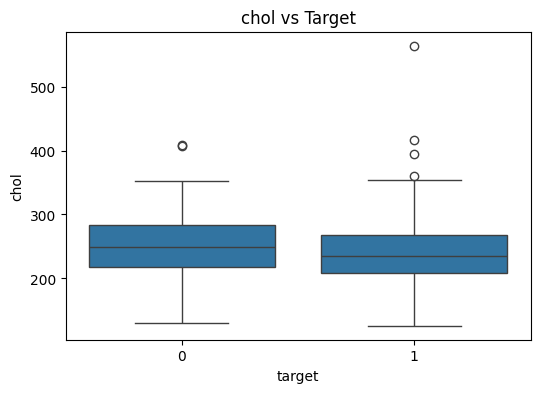

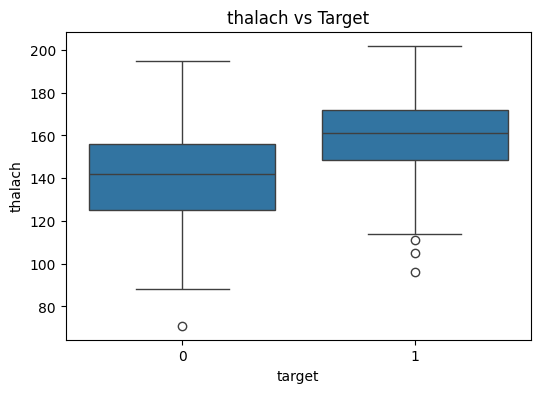

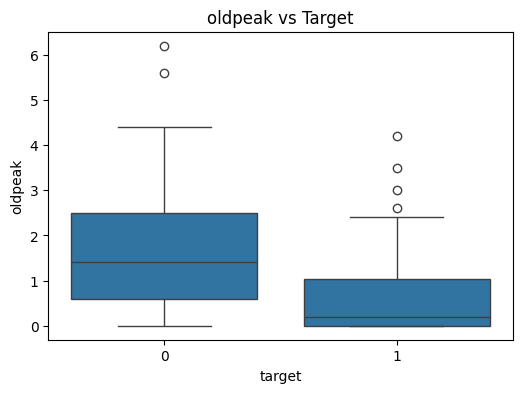

In [31]:
# bivariate analysis of continuous features with respect to the target variable

# continuous vs target

for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

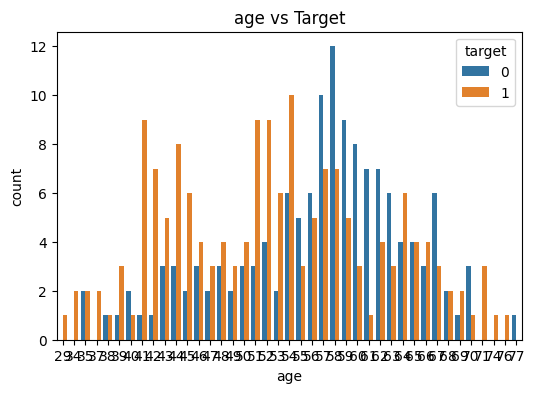

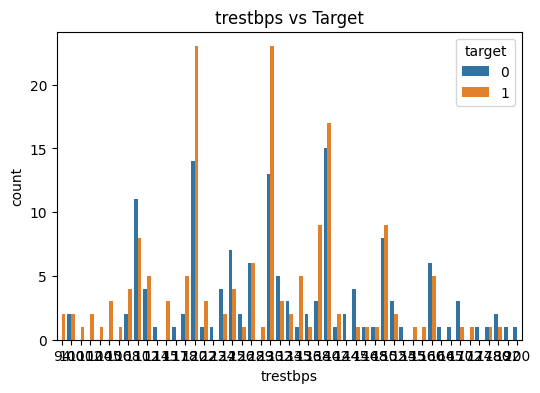

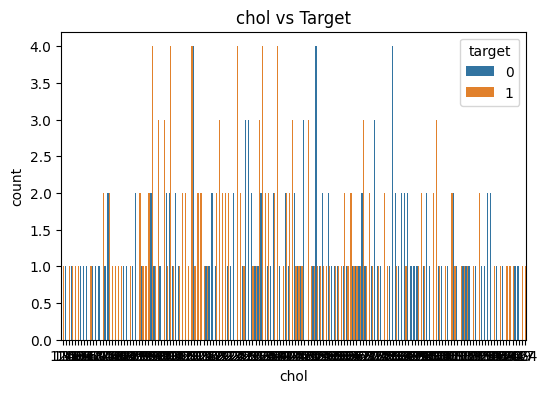

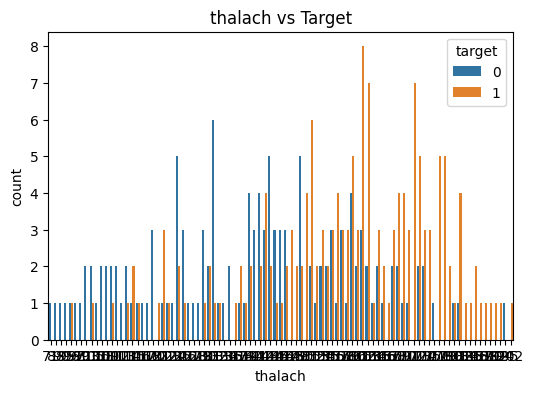

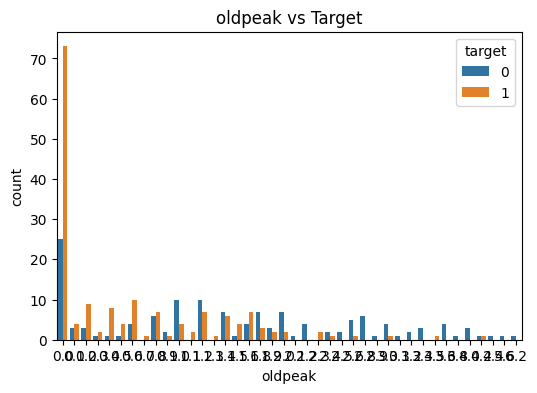

In [32]:
# categorical vs target

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f"{col} vs Target")
    plt.show()


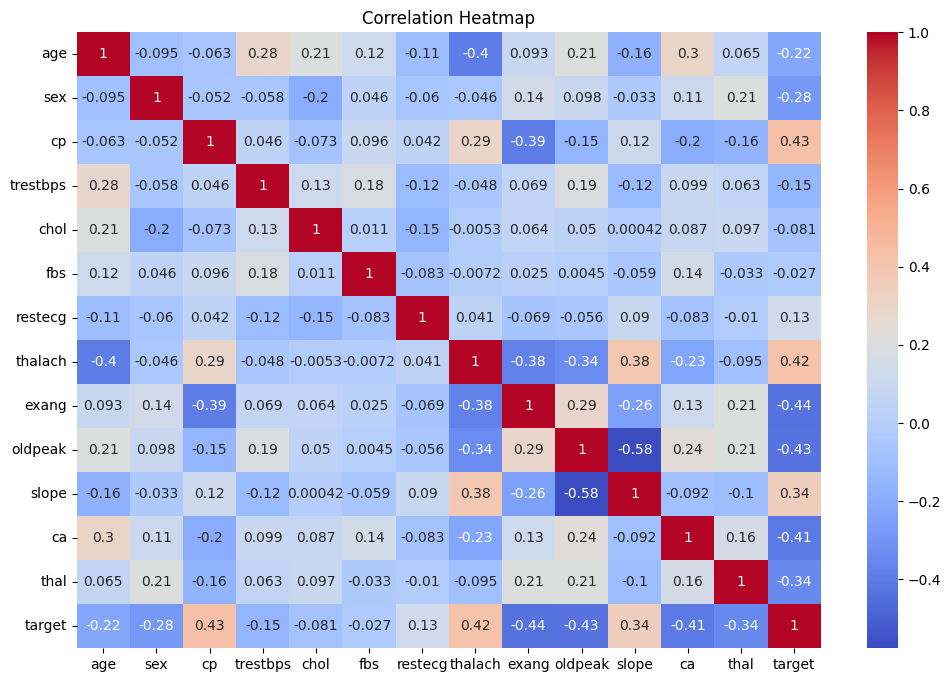

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# correlation heatmap of continuous features only

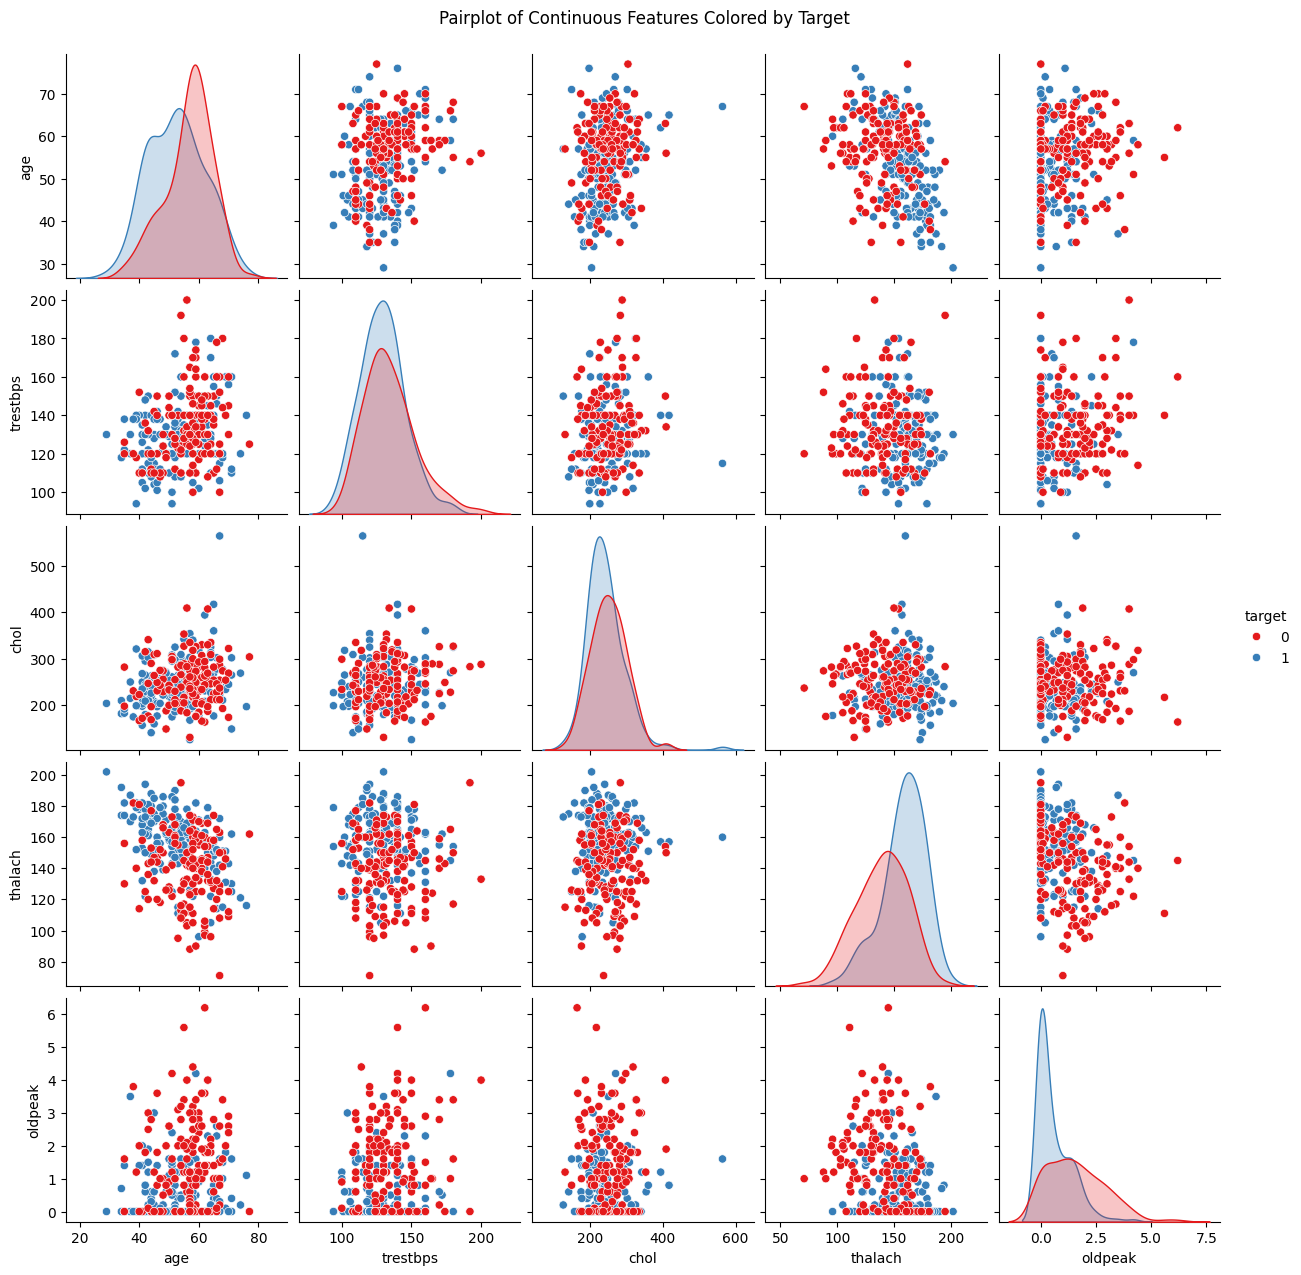

In [36]:
# pairplot of continuous features colored by target variable
sns.pairplot(df, vars=continuous_cols, hue='target', palette='Set1')
plt.suptitle("Pairplot of Continuous Features Colored by Target", y=1.02)
plt.show()